# Residual Analysis and Model Diagnostics

This notebook evaluates the residual behavior of the Simple Linear Regression model.

The analysis focuses on:

1. Residual construction
2. Residual mean
3. Residuals vs predicted values
4. Residuals vs predictor
5. Residual distribution
6. Q-Q plot
7. Homoscedasticity
8. Potential outliers
9. Leverage and influence
10. Implications of violating linear regression assumptions

The objective is not simply to measure predictive performance, but to determine whether the fitted linear model provides a reasonable representation of the observed data.

In [7]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split

In [2]:
PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

str(PROJECT_ROOT)

'/Users/shyamverma/ml_projects/slr_from_ols'

In [3]:
from src.linear_regression import SimpleLinearRegression
from src.metrics import mae, mse, rmse, r2_score

In [5]:
df = pd.read_csv(PROJECT_ROOT / "data" / "raw" / "Advertising.csv")

df.columns = ["Id", "TV", "Radio", "Newspaper", "Sales"]

df = df.drop(columns=["Id"])

df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [6]:
X = df["TV"].values
y = df["Sales"].values

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
model = SimpleLinearRegression()

model.fit(X_train, y_train)

In [10]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [11]:
train_residuals = y_train - y_train_pred
test_residuals = y_test - y_test_pred

In [12]:
print(train_residuals[:10])

[-1.51708754 -2.5554013   0.97493005 -0.31844084 -5.94229878 -1.29707426
  0.09536237  0.62653179 -1.58664858  1.33014289]


In [13]:
residual_summary = pd.DataFrame({
    "Residual": train_residuals
})

residual_summary.describe()

,Residual
count,1.600000e+02
mean,1.609823e-15
std,3.266541e+00
min,-8.194416e+00
25%,-2.056626e+00
50%,-1.943047e-01
75%,2.114028e+00
max,6.996278e+00


In [14]:
print("Sum of residuals:", np.sum(train_residuals))
print("Mean residual:", np.mean(train_residuals))

Sum of residuals: 2.575717417130363e-13
Mean residual: 1.609823385706477e-15


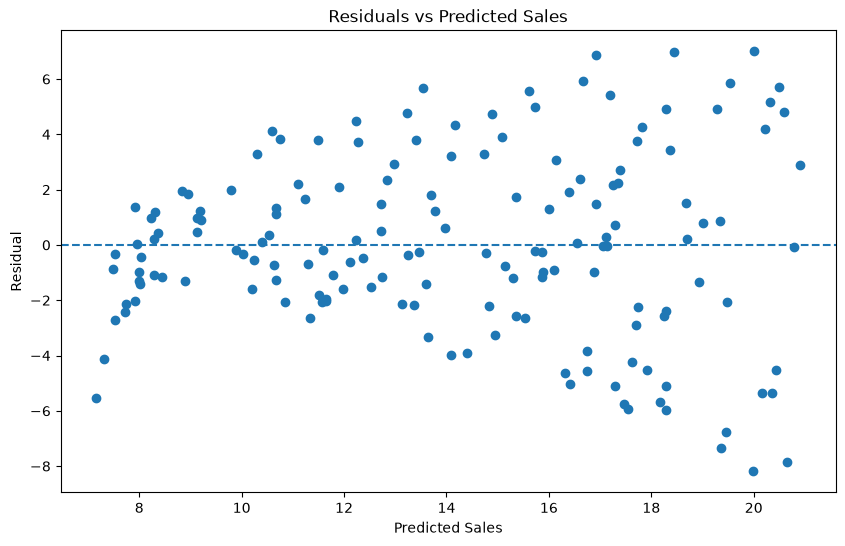

In [15]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_train_pred,
    train_residuals
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Sales")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Sales")

plt.show()

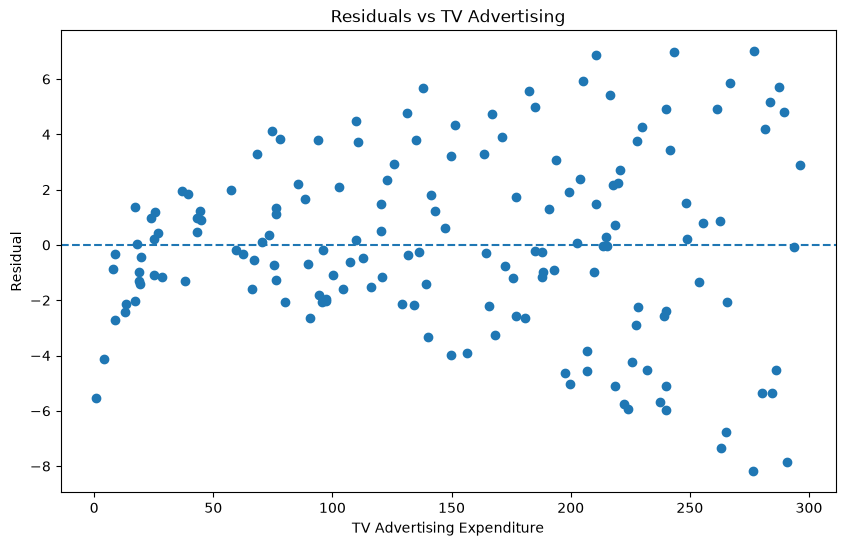

In [16]:
plt.figure(figsize=(10, 6))

plt.scatter(
    X_train,
    train_residuals
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("TV Advertising Expenditure")
plt.ylabel("Residual")
plt.title("Residuals vs TV Advertising")

plt.show()

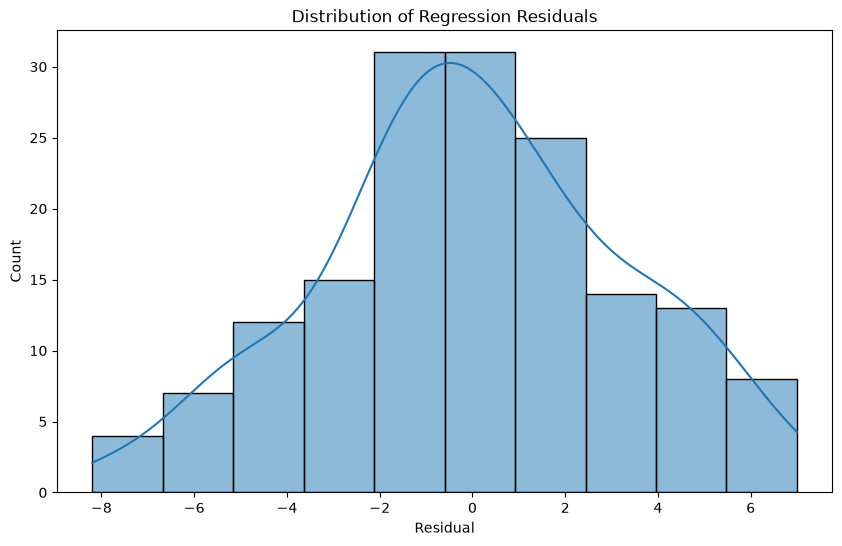

In [17]:
plt.figure(figsize=(10, 6))

sns.histplot(
    train_residuals,
    kde=True
)

plt.xlabel("Residual")
plt.title("Distribution of Regression Residuals")

plt.show()

# Conclusion

Residual analysis is an important part of evaluating a regression model because model performance metrics alone do not reveal how the model's errors are distributed.

In this notebook, we examined the residuals produced by the Simple Linear Regression model using the `TV` advertising expenditure feature.

## What We Examined

### 1. Residual Calculation

For each observation:

$$
e_i = y_i - \hat{y}_i
$$

The residual represents the prediction error for an individual observation.

### 2. Residual Summary

We examined the basic statistical properties of the residuals, including:

- Mean
- Standard deviation
- Minimum
- Maximum
- Quartiles

For an OLS model with an intercept, the residuals satisfy:

$$
\sum_{i=1}^{n} e_i \approx 0
$$

up to numerical precision.

### 3. Residuals vs Predicted Values

The residual-vs-predicted plot helps identify systematic patterns in model errors.

Ideally, residuals should:

- be centered around zero
- show no obvious systematic pattern
- have approximately constant spread across fitted values

A visible curve or systematic structure may indicate that a linear model is not adequately capturing the relationship.

### 4. Residuals vs Feature

We also examined residuals against the original predictor (`TV`).

This helps determine whether the prediction errors change systematically with the input variable.

For a well-specified linear relationship, we generally expect residuals to be scattered around zero without a strong systematic pattern.

### 5. Distribution of Regression Residuals

The distribution of residuals was visualized using a histogram and density estimate.

This helps us understand:

- whether residuals are approximately centered around zero
- whether the distribution is symmetric
- whether there are unusually large errors
- whether the residual distribution appears approximately bell-shaped

A roughly symmetric and centered distribution is consistent with one of the assumptions commonly used for classical statistical inference.

However, visual inspection alone does **not** prove that residuals are normally distributed.

## Key Takeaways

- Residuals provide information that aggregate metrics such as MAE, MSE, RMSE, and \(R^2\) cannot provide on their own.
- The residual-vs-predicted plot can reveal systematic patterns that suggest model misspecification.
- The residual-vs-feature plot helps investigate whether errors depend on the predictor.
- The residual distribution helps us understand the shape and spread of model errors.
- A residual mean close to zero is expected for OLS with an intercept, but it does not by itself prove that the model is appropriate.
- Residual analysis should be interpreted together with the model's assumptions and other diagnostics.